In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

In [3]:
# Load the dataset
data = fetch_california_housing()
X, y = data.data, data.target

In [4]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
eda = pd.DataFrame(data=X_train)
eda.columns = data.feature_names
eda['MedHouseVal'] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Considerando o intervalo de 25% a 75%, a maioria dos preços medianos das casas esta entre US$119.800 e US$265.125.

Text(0, 0.5, 'Frequency')

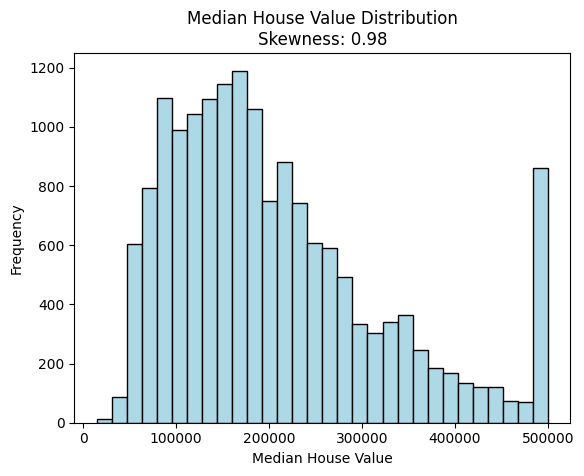

In [7]:
# Plot the distribution
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

In [8]:
# Initialize and fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf_regressor.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2556
Root Mean Squared Error (RMSE): 0.5055
R² Score: 0.8050


O erro absoluto médio é de US$ 32.760.

Portanto, em média, as previsões da mediana dos preços das casas apresentam uma diferença de aproximadamente US$ 33 mil em relação aos valores reais. O erro quadrático médio (MSE) é menos intuitivo de interpretar, mas geralmente é a métrica minimizada durante o ajuste do modelo.

Por outro lado, ao calcular a raiz quadrada do MSE, obtém-se um valor em dólares; neste caso, o RMSE é de US$ 50.550.

Um coeficiente de determinação (R-quadrado) de 0,80 não é considerado muito alto. Isso significa que o modelo explica cerca de 80% da variância na mediana dos preços das casas, embora essa interpretação possa ser enganosa no caso de dados complexos com relações não lineares, valores assimétricos e *outliers* (valores atípicos). Ainda assim, o R-quadrado pode ser útil para comparar modelos.

Essas estatísticas, por si sós, não detalham o desempenho do modelo.
Por exemplo: em quais situações o modelo teve um bom ou mau desempenho?

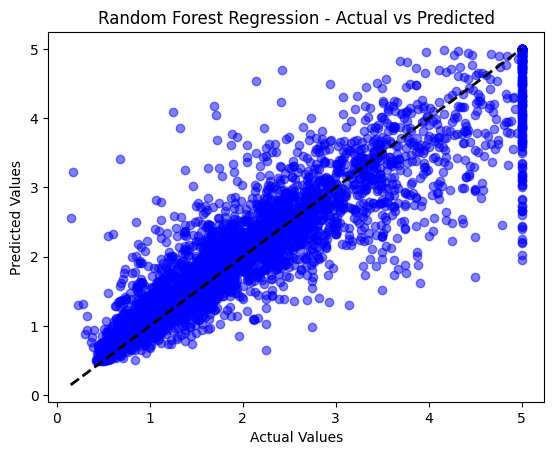

In [10]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs Predicted")
plt.show()

Average error = -1214
Standard deviation of error = 50537


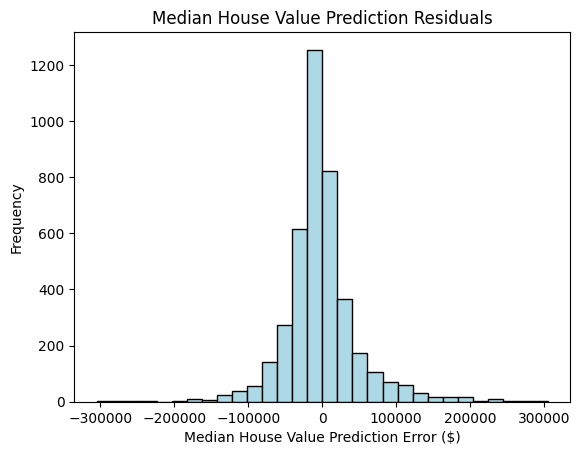

In [11]:
# Calculate the residual errors
residuals = 1e5*(y_test - y_pred_test)

# Plot the histogram of the residuals
plt.hist(residuals, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Prediction Residuals')
plt.xlabel('Median House Value Prediction Error ($)')
plt.ylabel('Frequency')
print('Average error = ' + str(int(np.mean(residuals))))
print('Standard deviation of error = ' + str(int(np.std(residuals))))

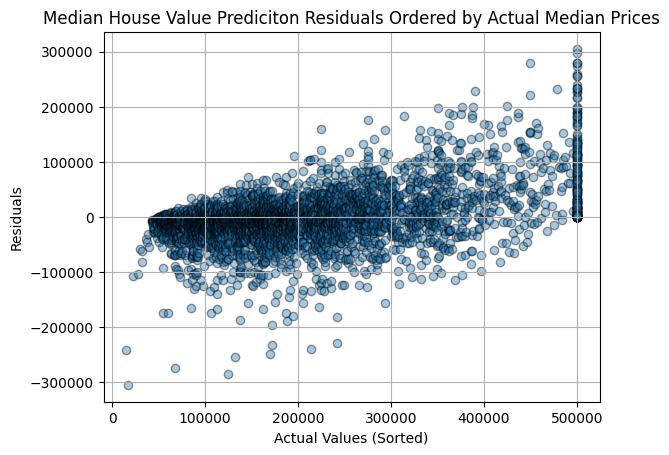

In [12]:
# Create a DataFrame to make sorting easy
residuals_df = pd.DataFrame({
    'Actual': 1e5*y_test,
    'Residuals': residuals
})

# Sort the DataFrame by the actual target values
residuals_df = residuals_df.sort_values(by='Actual')

# Plot the residuals
plt.scatter(residuals_df['Actual'], residuals_df['Residuals'], marker='o', alpha=0.4,ec='k')
plt.title('Median House Value Prediciton Residuals Ordered by Actual Median Prices')
plt.xlabel('Actual Values (Sorted)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Embora tenhamos observado um pequeno resíduo médio de apenas US$ 1.214, é possível notar neste gráfico que o erro médio, em função do preço mediano das casas, na verdade aumenta de valores negativos para positivos.
Em outras palavras, preços medianos mais baixos tendem a ter suas estimativas superestimadas, enquanto preços medianos mais altos tendem a ter suas estimativas subestimadas.

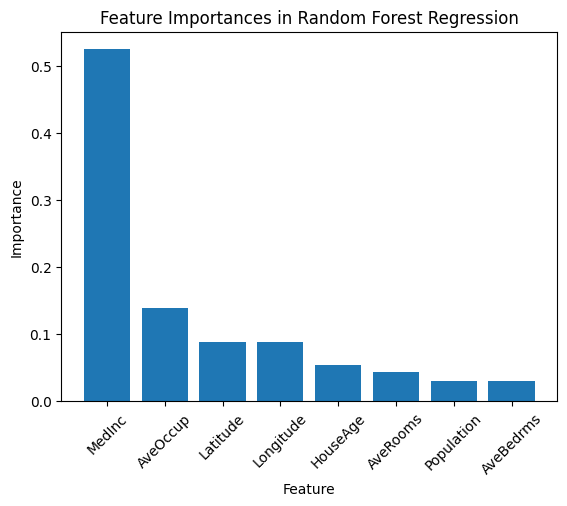

In [13]:
# Feature importances
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices],  align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

Faz sentido que a renda mediana e os preços das casas estejam correlacionados; portanto, não surpreende que a renda mediana seja a variável mais importante.

Imagino que a localização deva ser um fator significativo.

Como a localização está implícita em duas variáveis ​​distintas - latitude e longitude - que possuem a mesma importância, pode-se supor que a localização seja, na verdade, a segunda variável mais importante.
Isso ocorre porque substituir latitude e longitude por uma variável categórica de localização, em um nível de granularidade adequado (bairro, cidade, etc.), provavelmente resultaria em uma importância combinada (lat/long) capaz de superar a da ocupação média.

Será que a ocupação média e o número médio de quartos estão correlacionados?

Uma análise adequada do conjunto de variáveis ​​incluiria uma matriz de correlação.

Em comparação com a regressão linear, a regressão Random Forest é bastante robusta a outliers e distribuições assimétricas.
Isso ocorre porque a regressão Random Forest não faz suposições sobre a distribuição dos dados, ao passo que a regressão linear apresenta melhor desempenho com dados que seguem uma distribuição normal.

A padronização dos dados não é necessária, ao contrário do que ocorre com algoritmos baseados em distância, como KNN ou SVMs.

Quanto aos valores limitados (clipped values), não há variabilidade neles. Removê-los durante o pré-processamento pode ajudar o modelo a explicar melhor a variância real dos dados.

Esses valores limitados também podem enviesar as previsões.
Além disso, eles podem induzir a erros na interpretação das métricas de avaliação. Como você aprendeu neste laboratório, é fundamental visualizar os resultados.
